In [22]:
%pip install scikit-learn

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
image_path = "../output_videos/cropped_img.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

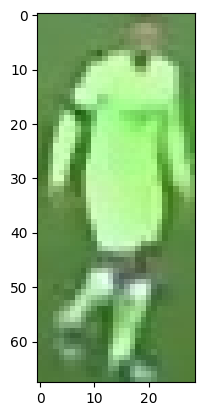

In [24]:
plt.imshow(image)
plt.show()

Top half of image

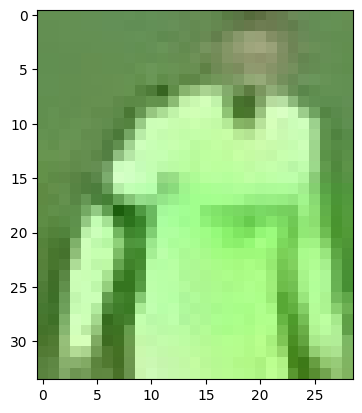

In [25]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

Cluster image into two clusters

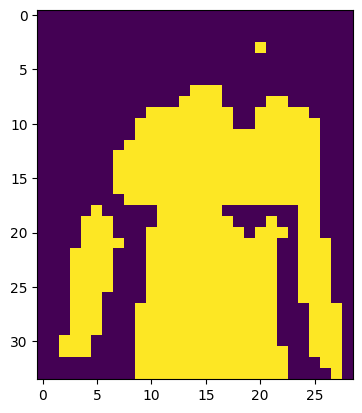

In [26]:
#Reshape the image into 2s array 
image_2d = top_half_image.reshape(-1, 3)

#Perform k means clustering
kmeans = KMeans(n_clusters =2, random_state = 0)
kmeans.fit(image_2d)

labels = kmeans.labels_

#Reshape the labels into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0],top_half_image.shape[1])

plt.imshow(clustered_image)
plt.show()

In [27]:
corner_clusters = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]
non_player_cluster = max(set(corner_clusters), key = corner_clusters.count)
print(non_player_cluster)

0


In [28]:
player_cluster = 1-non_player_cluster
print(player_cluster)

1


In [29]:
kmeans.cluster_centers_[player_cluster]

array([177.64044944, 244.51235955, 151.71235955])